<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/IyC_2026_DML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Impacto del plan 401(k) en Riqueza Financiera


Como caso práctico del método DML, consideramos la estimación del efecto de la elegibilidad y participación en planes 401(k) sobre los activos acumulados. Los planes 401(k) son cuentas de pensión patrocinadas por los empleadores. El problema clave al determinar el efecto de la participación en planes 401(k) sobre los activos acumulados es la **heterogeneidad de los ahorradores**, junto con el hecho de que la decisión de inscribirse en un 401(k) **no es aleatoria**.

Generalmente se reconoce que algunas personas tienen una mayor preferencia por el ahorro que otras. También parece probable que aquellos individuos con una alta preferencia no observada por el ahorro sean los más propensos a elegir participar en planes de ahorro para el retiro con ventajas fiscales y tenderían a tener altas cantidades de activos acumulados. La presencia de preferencias de ahorro no observadas con estas propiedades implica  que las estimaciones convencionales que **no toman en cuenta la heterogeneidad de los ahorradores** y la **endogeneidad** de la participación estarán **sesgadas a la alza**, tendiendo a sobreestimar los efectos de la participación en un 401(k) sobre el ahorro.

Se puede argumentar que la elegibilidad para inscribirse en un plan 401(k) en estos datos puede ser considerada como **exógena** después de condicionar en algunas variables observables, de las cuales la más importante para su argumento es el ingreso. La idea básica es que, al menos en la época en que los 401(k) estuvieron disponibles inicialmente, era poco probable que las personas basaran sus decisiones de empleo en si un empleador ofrecía un 401(k), sino que se enfocarían en el ingreso y otros aspectos del trabajo.

## Recordamos los supuestos de causalidad
- Ignorabilidad (independencia).  ${ Y(0), Y(1) } ⊥ X | Z$.  Los resultados potenciales son independientes de la asignación al tratamiento, una vez que condicionamos en el conjunto de covariables Z.

- Positividad (overlap). $P(X = x | Z = z) > 0$. Es decir, ningún estrato de la población tiene probabilidad cero de recibir cualquier nivel del tratamiento.

- SUTVA. $Y_i(x)$ no depende de $X_j$ para ningún $j \neq i$. El resultado de la unidad i no cambia según cómo se asigne el tratamiento a otras unidades.

No-Ejemplo: Si vacuno a tus vecinos, tu riesgo de enfermar baja aunque tú no te vacunes. El resultado $Y_i$ depende del tratamiento de $X_j$


### Borrar metadatos del documento original


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
### Celda para eliminar los metadatos y hacer el notebook compatible con Github
#import json

#nombre = "/content/drive/MyDrive/Colab Notebooks/IyC_2026_DML.ipynb"

#with open(nombre, "r", encoding="utf-8") as f:
#    nb = json.load(f)

### Si existen metadatos de widgets de ipywidgets, los eliminamos

#if "widgets" in nb.get("metadata",{}):
#    del nb["metadata"]["widgets"]

#with open(nombre,"w", encoding="utf-8") as f:
#    json.dump(nb,f,indent=1, ensure_ascii=False)

#print("Listo")

### Guardamos el notebook limpio

#with open(nombre, "w", encoding="utf-8") as f:
#    json.dump(nb, f, indent=1, ensure_ascii=False)

#print("Archivo guardado correctamente")

### Datos

In [3]:
# - wget: para descargar archivos desde URL
# - formulaic: para especificar formulas de transformacion de variables (similar a R)

!pip install wget
!pip install formulaic

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=483ce3a8a4e8d489326caed9e8caa50c2a29d731689ef1471a50f4e05ff8d2da
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.8 MB/s eta 0:00:00


In [4]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import make_pipeline ### Cadena de transformaciones + modelo
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier ### Gradient Boosting para regresion (modelo de Y)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier #### Gradient Boosting para clasificacion (modelo de D)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.base import TransformerMixin, BaseEstimator, clone
from IPython.display import Markdown
import wget
import seaborn as sns
from formulaic import Formula ### Creacion de matrices de diseno con formulas estilo R
import warnings
warnings.simplefilter('ignore')
np.random.seed(1234)

In [5]:
# Fuente: Chernozhukov et al. - MetricsMLNotebooks (GitHub)

file = "https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/401k.csv"
data = pd.read_csv(file)

In [6]:
data.describe()

,ira,a401,hval,hmort,hequity,nifa,net_nifa,tfa,net_tfa,tfa_he,...,i3,i4,i5,i6,i7,a1,a2,a3,a4,a5
count,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9.915000e+03,9.915000e+03,9.915000e+03,9.915000e+03,9.915000e+03,...,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000
mean,3462.871609,3990.459304,63595.865759,30022.505093,33573.360666,1.392864e+04,1.041415e+04,2.156603e+04,1.805153e+04,5.162490e+04,...,0.209178,0.172668,0.121432,0.158548,0.077358,0.144024,0.209682,0.297428,0.215431,0.133434
std,9648.027853,12825.840676,73679.374267,40056.879558,51830.770524,5.490488e+04,5.602886e+04,6.256504e+04,6.352250e+04,9.325339e+04,...,0.406742,0.377979,0.326645,0.365272,0.267171,0.351132,0.407102,0.457150,0.411142,0.340061
min,0.000000,0.000000,0.000000,0.000000,-40000.000000,0.000000e+00,-5.023020e+05,0.000000e+00,-5.023020e+05,-5.023020e+05,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+02,-1.350000e+03,3.750000e+02,-5.000000e+02,2.000000e+02,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,48000.000000,7000.000000,10000.000000,1.635000e+03,2.700000e+02,3.325000e+03,1.499000e+03,1.850000e+04,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,200.000000,95000.000000,50000.000000,46650.000000,8.765500e+03,6.543500e+03,1.908450e+04,1.652450e+04,6.920000e+04,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,100000.000000,153000.000000,300000.000000,150000.000000,300000.000000,1.430298e+06,1.430298e+06,1.536798e+06,1.536798e+06,1.687115e+06,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
data.head()

,ira,a401,hval,hmort,hequity,nifa,net_nifa,tfa,net_tfa,tfa_he,...,i3,i4,i5,i6,i7,a1,a2,a3,a4,a5
0,0,0,69000,60150,8850,100,-3300,100,-3300,5550,...,1,0,0,0,0,0,1,0,0,0
1,0,0,78000,20000,58000,61010,61010,61010,61010,119010,...,0,1,0,0,0,0,0,0,1,0
2,1800,0,200000,15900,184100,7549,7049,9349,8849,192949,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,2487,-6013,2487,-6013,-6013,...,0,0,1,0,0,1,0,0,0,0
4,0,0,300000,90000,210000,10625,-2375,10625,-2375,207625,...,0,1,0,0,0,0,0,1,0,0


- Descarga y renderizado del README del dataset (diccionario de variables)
- Explica que significa cada columna: activos, elegibilidad, ingreso, etc.


In [8]:
readme = "https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/401k.md"
filename = wget.download(readme)
Markdown(open(filename, 'r').read())

# Pension 401(k) data set

## Description
Data set on financial wealth and 401(k) plan participation. The source of this data set is the `hdm` package in `R`. It was created on 2/20/2023, by calling the `data(pension)` command in `R` after loading the `hdm` package and then writing the created dataframe to a csv file.

## Format
Dataframe with the following variables (amongst others):

**p401**

participation in 401(k)

**e401**

eligibility for 401(k)

**a401**

401(k) assets

**tw**

total wealth (in US $)

**tfa**

financial assets (in US $)

**net_tfa**

net financial assets (in US $)

**nifa**

non-401k financial assets (in US $)

**net_nifa**

net non-401k financial assets

**net_n401**

net non-401(k) assets (in US $)

**ira**

individual retirement account (IRA)

**inc**

income (in US $)

**age**

age

**fsize**

family size

**marr**

married

**pira**

participation in IRA

**db**

defined benefit pension

**hown**

home owner

**educ**

education (in years)

**male**

male

**twoearn**

two earners

**nohs, hs, smcol, col**

dummies for education: no high-school, high-school, some college, college

**hmort**

home mortage (in US $)

**hequity**

home equity (in US $)

**hval**

home value (in US $)

**i1-i7**

are income category indicators, 

**a1-a5**

are age category indicators

**icat** 

is the categorical variable that produces i1-i7. 

**ecat** 

is the categorical variable that generates education dummies (no high school, high school, some college, college). 

**Dum91**

is a dummy for 1991 which is equal to 1 for all observations because we are only use the 1991 SIPP. 

**tfa_he**

is net_tfa + home equity.

**zhat**

outcome of first stage prediction in instrumental variable analysis, from the academic paper that introduced this data


## Details
The sample is drawn from the 1991 Survey of Income and Program Participation (SIPP) and consists of 9,915 observations. The observational units are household reference persons aged 25-64 and spouse if present. Households are included in the sample if at least one person is employed and no one is self-employed. The data set was analysed in Chernozhukov and Hansen (2004) and Belloni et al. (2014) where further details can be found. They examine the effects of 401(k) plans on wealth using data from the Survey of Income and Program Participation using 401(k) eligibility as an instrument for 401(k) participation.

## References
V. Chernohukov, C. Hansen (2004). The impact of 401(k) participation on the wealth distribution: An instrumental quantile regression analysis. The Review of Economic and Statistics 86 (3), 735–751.

A. Belloni, V. Chernozhukov, I. Fernandez-Val, and C. Hansen (2014). Program evaluation with high-dimensional data. Working Paper.

## La idea general del DML


Utilizamos dos modelos:

1. Cuantificar la influencia de las variables predictoras en el outcome.

2. Para ver la influencia de las variables predictoras en el tratamiento.

Teóricamente estas no deberían influir en la asignación del tratamiento.

Ya que estimamos ambas, obtendremos el residuo de ambas para obtener el efecto causal. Esto se hace para limpiar la influencia de las variables confusores del efecto real de la egebilidad.

Recordemos: Buscamos el efecto de la eligibilidad `D = e401` en la riqueza de una persona `Y = net_tfa` = los activos financieros netos.




### Los datos

Los datos constan de 9,915 observaciones a nivel de hogar, extraídas de la Encuesta de Ingresos y Participación en Programas (SIPP, por sus siglas en inglés) de 1991. En nuestro análisis, utilizamos los **activos financieros netos** (*net\_tfa*) como la variable de resultado, $Y$. Los activos financieros netos se calculan como la suma de los saldos de cuentas IRA, saldos de planes 401(k), cuentas corrientes, bonos de ahorro, otras cuentas que generan intereses, otros activos que generan intereses, acciones y fondos de inversión, menos las deudas no hipotecarias.

### La Elegibilidad

De los $9915$ individuos, $3682$ son **elegibles** para participar en el programa. La variable *e401* indica la **elegibilidad** y *p401* la **participación**, respectivamente.

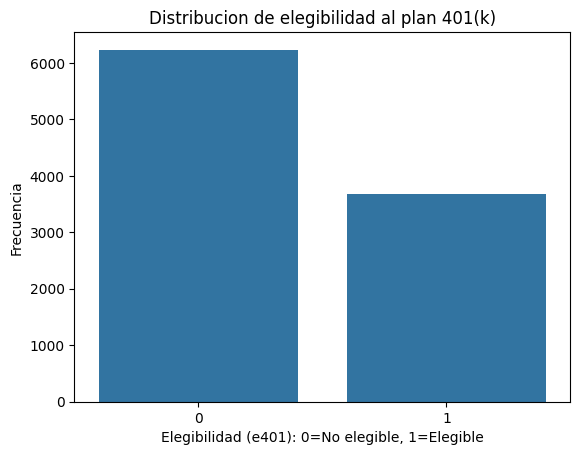

In [9]:
# Conteo de individuos elegibles (e401=1) vs no elegibles (e401=0)
# Primer vistazo al desbalance en la variable de tratamiento
sns.countplot(data, x='e401')
plt.title("Distribucion de elegibilidad al plan 401(k)")
plt.xlabel("Elegibilidad (e401): 0=No elegible, 1=Elegible")
plt.ylabel("Frecuencia")
plt.show()

Elegibilidad en el programa sí está asociada con riqueza financiera acumulada:

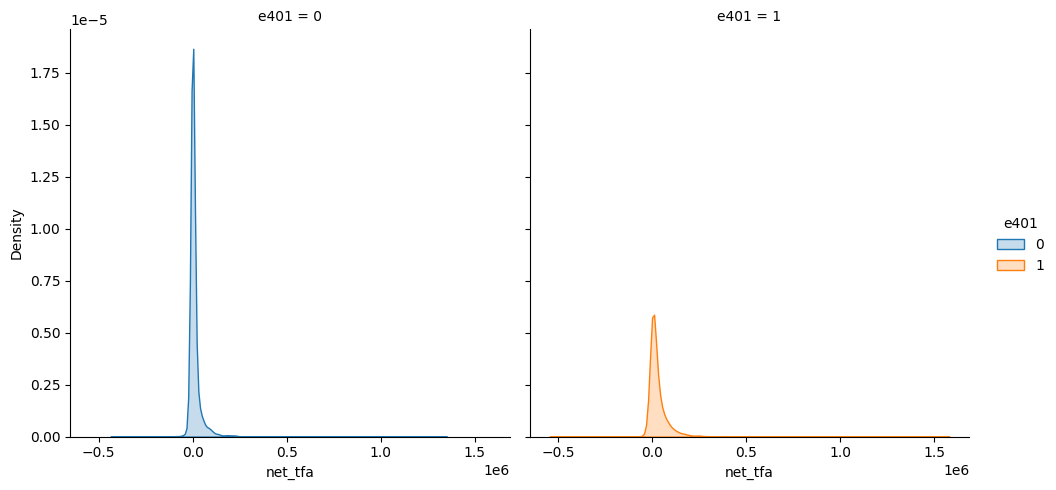

In [10]:
# Distribucion de activos financieros netos (net_tfa) condicionada en elegibilidad
# Evidencia visual de que los elegibles tienen, en promedio, mas activos
# ADVERTENCIA: esta diferencia NO es causal; puede reflejar seleccion (confounding)
sns.displot(data=data, x='net_tfa', kind='kde', col='e401', hue='e401', fill=True)
plt.show()

El "Average predictive effect" (APE) es aprox $19559$:

Cuidado:  Este no es un valor causal, es la diferencia de medidas sin controlar por ninguna variable de confusión. Sobreestima el efecto real porque los individuos elegibles también tienen mayor disposición al ahorro.

In [37]:
# Distribucion de activos financieros netos (net_tfa) condicionada en elegibilidad
# Evidencia visual de que los elegibles tienen, en promedio, mas activos

e1 = data[data['e401'] == 1]['net_tfa']
e0 = data[data['e401'] == 0]['net_tfa']
print(f'{np.mean(e1) - np.mean(e0):.0f}')

19559


El **Efecto Predictivo Promedio (APE)** incondicional de la elegibilidad (*e401*) es aproximadamente $19 559$:


De los $3682$ individuos elegibles, $2594$ decidieron **participar** en el programa. El **APE (Efecto Predictivo Promedio)** incondicional de p401 es de aproximadamente $27372$:

In [12]:
# Diferencia de medias de net_tfa entre participantes y no participantes
# APE incondicional de p401 tambien sesgado
e1 = data[data['p401'] == 1]['net_tfa']
e0 = data[data['p401'] == 0]['net_tfa']
print(f'APE incondicional de p401: {np.mean(e1) - np.mean(e0):.0f}')

APE incondicional de p401: 27372


Notemos que estos valores estimados están sesgados ya que no toman en cuenta la heterogeneidad (no observada) de los ahorradores. Para obtener una estimación causal válida, utilizaremos Double Machine Learning

## Definición de variables

In [13]:
# -- Definicion del resultado (Y), tratamientos (D) y controles (X) --

# Y: variable de resultado -- activos financieros netos
y = data['net_tfa'].values

# D: tratamiento principal -- elegibilidad al plan 401(k)
D  = data['e401'].values

# D2, D3: tratamientos alternativos (para analisis de robustez)
D2 = data['p401'].values   # participacion efectiva en el plan
D3 = data['a401'].values   # tenencia de activos 401(k)

# X: covariables de control
# Se eliminan: variables de resultado, otras medidas de activos correlacionadas,
# y variables categoricas derivadas (icat, ecat, etc.) para evitar post-tratamiento
X = data.drop(['e401', 'p401', 'a401',        ### tratamientos
               'tw', 'tfa', 'net_tfa',         ### variables de resultado
               'tfa_he', 'hval', 'hmort', 'hequity',
               'nifa', 'net_nifa', 'net_n401', 'ira',
               'dum91', 'icat', 'ecat', 'zhat',
               'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7',
               'a1', 'a2', 'a3', 'a4', 'a5'], axis=1)
X.columns

Index(['age', 'inc', 'fsize', 'educ', 'db', 'marr', 'male', 'twoearn', 'pira',
       'nohs', 'hs', 'smcol', 'col', 'hown'],
      dtype='object')

In [14]:
D

array([0, 0, 0, ..., 1, 1, 1])

### Transformacion de controles: Feature Engineering

Para que los modelos de ML capturen relaciones no lineales entre las covariables y tanto el resultado ($Y$) como el tratamiento ($D$), expandimos el espacio de caracteristicas mediante **polinomios** (para considerar distintos grados de una misma variable).

Esto es crucial en DML: si los modelos de primer paso son demasiado simples (ej. regresion lineal sin transformaciones), entonces los residuos quedan contaminados con sesgos, y el estimador causal final tambien resulta sesgado.

La flexibilidad del primer paso es lo que garantiza la **ortogonalizacion** correcta.

In [15]:
# -- Transformador de formula compatible con scikit-learn
# Permite usar sintaxis tipo R (ej. poly(), interacciones) dentro de un pipeline de sklearn
class FormulaTransformer(TransformerMixin, BaseEstimator):
    """
    Transforma un DataFrame usando una formula de tipo R (via `formulaic`).
    Compatible con pipelines de scikit-learn (fit/transform).
    """
    def __init__(self, formula, array=False):
        self.formula = formula   # Formula de transformacion (string estilo R)
        self.array = array       # Si True, devuelve numpy array; si False, DataFrame

    def fit(self, X, y=None):
        # No requiere ajuste (stateless): la formula se aplica directamente
        return self

    def transform(self, X, y=None):
        # Genera la matriz de diseno segun la formula especificada
        df = Formula(self.formula).get_model_matrix(X)
        if self.array:
            return df.values  # Algunos modelos sklearn requieren numpy arrays
        return df

In [16]:
#  Especificacion de la formula de expansion polinomial
# Variables continuas expandidas con polinomios de distintos grados:
#   age  (edad):      hasta grado 6
#   inc  (ingreso):   hasta grado 8  <- Más flexible porque el ingreso es el confusor mas importante
#   educ (educacion): hasta grado 4
#   fsize (tamano del hogar): hasta grado 2
# Variables binarias incluidas directamente: male, marr, twoearn, db, pira, hown
# El "0 +" suprime el intercepto en la formula
transformer = FormulaTransformer(
    "0 + poly(age, degree=6, raw=True) + poly(inc, degree=8, raw=True) "
    "+ poly(educ, degree=4, raw=True) + poly(fsize, degree=2, raw=True) "
    "+ male + marr + twoearn + db + pira + hown")

In [17]:
# Verifica la matriz de diseno
# Permite revisar rangos, medias y que no haya valores faltantes

transformer.fit_transform(X).describe()

,"poly(age, degree=6, raw=True)[0]","poly(age, degree=6, raw=True)[1]","poly(age, degree=6, raw=True)[2]","poly(age, degree=6, raw=True)[3]","poly(age, degree=6, raw=True)[4]","poly(age, degree=6, raw=True)[5]","poly(inc, degree=8, raw=True)[0]","poly(inc, degree=8, raw=True)[1]","poly(inc, degree=8, raw=True)[2]","poly(inc, degree=8, raw=True)[3]",...,"poly(educ, degree=4, raw=True)[2]","poly(educ, degree=4, raw=True)[3]","poly(fsize, degree=2, raw=True)[0]","poly(fsize, degree=2, raw=True)[1]",male,marr,twoearn,db,pira,hown
count,9915.000000,9915.000000,9915.000000,9.915000e+03,9.915000e+03,9.915000e+03,9915.000000,9.915000e+03,9.915000e+03,9.915000e+03,...,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000
mean,41.060212,1792.938981,82850.255371,4.022991e+06,2.036867e+08,1.067384e+10,37200.623197,1.997590e+09,1.437534e+14,9.104568e+17,...,2601.853757,38237.377912,2.865860,10.581241,0.205951,0.604841,0.380837,0.271004,0.242158,0.635199
std,10.344505,899.134499,61725.701911,3.939869e+06,2.448502e+08,1.507229e+10,24774.288006,3.026128e+09,4.129207e+14,3.249753e+18,...,1464.892397,28259.732691,1.538937,11.391608,0.404415,0.488909,0.485617,0.444500,0.428411,0.481399
min,25.000000,625.000000,15625.000000,3.906250e+05,9.765625e+06,2.441406e+08,-2652.000000,0.000000e+00,-1.865179e+10,-9.222694e+18,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,1024.000000,32768.000000,1.048576e+06,3.355443e+07,1.073742e+09,19413.000000,3.768646e+08,7.316072e+12,3.677463e+16,...,1728.000000,20736.000000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.000000,1600.000000,64000.000000,2.560000e+06,1.024000e+08,4.096000e+09,31476.000000,9.907386e+08,3.118449e+13,4.226261e+17,...,1728.000000,20736.000000,3.000000,9.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,48.000000,2304.000000,110592.000000,5.308416e+06,2.548040e+08,1.223059e+10,48583.500000,2.360356e+09,1.146744e+14,2.117477e+18,...,4096.000000,65536.000000,4.000000,16.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,64.000000,4096.000000,262144.000000,1.677722e+07,1.073742e+09,6.871948e+10,242124.000000,5.862403e+10,1.419428e+16,9.222042e+18,...,5832.000000,104976.000000,13.000000,169.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
# Redefine el transformer con array=True
# Algunos modelos de sklearn (ej. RandomForest, GradientBoosting) requieren
# numpy arrays como entrada; esta version lo garantiza
transformer = FormulaTransformer(
    "0 + poly(age, degree=6, raw=True) + poly(inc, degree=8, raw=True) "
    "+ poly(educ, degree=4, raw=True) + poly(fsize, degree=2, raw=True) "
    "+ male + marr + twoearn + db + pira + hown",
    array=True   # devuelve numpy array para compatibilidad con sklearn. No regresa un dataframe, regresa un array
)

# Calculo del ATE de la elegibilidad del plan 401k en los Activos Financieros Netos

Queremos estimadores válidos del efecto promedio del tratamiento (ATE) de  `e401` en `net_tfa`. Utilizamos modelos de ML para estimar las funciones $g_0$ y $m_0$ en el siguiente modelo de Regresión lineal parcial (no es exactamente lineal porque no sabemos si $g_0$ lo es). Tampoco podemos asegurar que $m_0$ es lineal

\begin{eqnarray}
 &  Y = D\theta_0 + g_0(X) + \zeta, \quad &  E[\zeta \mid D,X]= 0,\\
 & D = m_0(X) +  V,  \quad  &  E[V \mid X] = 0.
\end{eqnarray}

**Donde:**
- $Y$ = activos financieros netos (`net_tfa`) -- **output**
- $D$ = elegibilidad al 401(k) (`e401`) -- **tratamiento**
- $\theta_0$ = **efecto causal promedio (ATE)** que queremos estimar
- $g_0(X)$ = funcion desconocida que captura el efecto de los controles sobre $Y$.
- $m_0(X)$ = funcion desconocida que captura el efecto de los controles sobre $D$ (propensity score)
- $\zeta$, $V$ = errores idiosincraticos ortogonales a los controles $X$.

**Intuicion:**
- La primera ecuacion dice que, condicional en $X$, el efecto de $D$ sobre $Y$ es lineal y constante igual a $\theta_0$.
- La segunda ecuacion descompone el tratamiento en una parte predecible por $X$ (posible sesgo de seleccion) y una parte aleatoria $V$.

## Double ML: en Regresión Lineal Parcial

Definimos una la siguiente función, la cual recibe como parámetros modelos de ML y devuelve el efecto del tratamiento y otros estadísticos útiles.

### Double ML: Algoritmo de Cross-Fitting

La idea central del **Double ML** (Chernozhukov et al., 2018) es la **ortogonalizacion de Frisch-Waugh** llevada al entorno no parametrico:

1. **Primer paso - nuisance models:** Predecir $Y$ y $D$ usando ML con *cross-fitting*
   - $\hat{g}_0(X) \approx E[Y \mid X]$ usando cualquier modelo de ML
   - $\hat{m}_0(X) \approx E[D \mid X]$ usando cualquier modelo de ML
2. **Calculo de residuos:**
   - $\tilde{Y} = Y - \hat{g}_0(X)$ (resultado neto de los controles)
   - $\tilde{D} = D - \hat{m}_0(X)$ (tratamiento neto de los controles)
3. **Segundo paso - estimacion causal:** Regresar $\tilde{Y}$ sobre $\tilde{D}$:
   $$\hat{\theta}_0 = \frac{\sum \tilde{D}_i \tilde{Y}_i}{\sum \tilde{D}_i^2}$$

El **cross-fitting** (prediccion fuera de muestra via K-Fold) es crucial para eliminar el sesgo de regularizacion del primer paso y garantizar inferencia valida sobre $\theta_0$.

In [39]:
def dml(X, D, y, modely, modeld, *, nfolds, classifier=False):
    '''
    DML for the Partially Linear Model setting with cross-fitting

    Input
    -----
    X: Matriz de controles o covariables
    D: Vector de tratamiento
    y: resultado
    modely: modelo para estimar el outcome y. Específicamente E[Y|X]
    modeld: modelo para estimar el tratamiento D. Específicamente E[D|X]
    nfolds: numero de 'folds' para la validación cruzada
    classifier: booleano, si el modelo es clasificador o regresor

    Output
    ------
    point: valor estimado puntual del efecto del tratamiento D sobre y. ATE (theta_0)
    stderr: error estandar del treatment effect
    yhat: predicciones del resultado y con cross-fitting
    Dhat: predicciones del tratamiento D con cross-fitting
    Dhat: the cross-fitted predictions for the treatment D
    resy: los residuales de y
    resD: los residuales del tratamiento
    epsilon: residuo final de la regresión OLS entre residuos.
    '''
    ### PASO 1a: Cross-fitting para Y
    cv = KFold(n_splits=nfolds, shuffle=True, random_state=123)  # shuffled k-folds

    # yhat = E[Y|X] estimado con ML; el cross-fitting evita overfitting en residuos
    # (cada prediccion se hace con un modelo entrenado SIN ese dato)

    yhat = cross_val_predict(modely, X, y, cv=cv, n_jobs=-1)  # predicciones para y
    # predicciones para D,  usamos predict or predict_proba dependiendo
    # de si es clasificador o regressor for D

    ## CLSIFICANDO
    if classifier:
        Dhat = cross_val_predict(modeld, X, D, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    else:
        Dhat = cross_val_predict(modeld, X, D, cv=cv, n_jobs=-1)

    ### PASO 2: Calculo de residuos
    # calcumos residuos o residuales de y y del tratamiento
    resy = y - yhat
    resD = D - Dhat

    ### PASO 3: Regresion de residuos sobre residuos (OLS)
    # ultima regresión con los residuos
    point = np.mean(resy * resD) / np.mean(resD**2)

    ### PASO 4: Inferencia. Error estandar
    epsilon = resy - point * resD
    var = np.mean(epsilon**2 * resD**2) / np.mean(resD**2)**2
    stderr = np.sqrt(var / X.shape[0])

    return point, stderr, yhat, Dhat, resy, resD, epsilon

Construye una tabla de resultados con el ATE estimado e indicadores de calidad de los modelos de primer paso (nuisance models).
Una buena estimacion causal requiere buenos modelos de primer paso:
menor RMSE en y y D implica residuos mas limpios y mejor estimacion de theta.

In [40]:
#Estadísticos resumen
def summary(point, stderr, yhat, Dhat, resy, resD, epsilon, X, D, y, *, name):

    return pd.DataFrame({'estimate': point,  # estimador puntual
                         'stderr': stderr,  #  error estandar
                         'lower': point - 1.96 * stderr,  #  límite inferior IC al 95%
                         'upper': point + 1.96 * stderr,  #  límite superior IC al 95%
                         'rmse y': np.sqrt(np.mean(resy**2)),  # RMSE del resultado y
                         'rmse D': np.sqrt(np.mean(resD**2)),  # RMSE del tratamiento D
                         'accuracy D': np.mean(np.abs(resD) < .5),  # binary classification accuracy of model for D
                         }, index=[name])

#### Lasso Doble con Cross-Fitting

Primer modelo DML: se usa **Lasso con validacion cruzada** tanto para el modelo de $Y$ como para el de $D$.

El Lasso selecciona automaticamente las variables mas relevantes entre todas las expansiones polinomiales, penalizando los coeficientes de variables irrelevantes hacia cero.

In [41]:
# Double Lasso
cv = KFold(n_splits=5, shuffle=True, random_state=123)
lassoy = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv))
lassod = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv)) ### También podría ser Ridge
result = dml(X, D, y, lassoy, lassod, nfolds=5)

In [42]:
table = summary(*result, X, D, y, name='double lasso')
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,9035.120004,1295.135748,6496.653938,11573.58607,54254.468883,0.443406,0.688553


#### Regression Logística para la estimación de D

In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=123)
lassoy = make_pipeline(transformer, StandardScaler(), LassoCV(cv=cv))
lgrd = make_pipeline(transformer, StandardScaler(), LogisticRegressionCV(cv=cv))
result = dml(X, D, y, lassoy, lgrd, nfolds=5, classifier=True)  ### Ojo, aquí si lo considera como clasificador

In [24]:
summary(*result, X, D, y, name='lasso/logistic') ## El * pide el resultado total del DML, por lo que ya arroja el ATE

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
lasso/logistic,9092.521633,1304.407597,6535.882744,11649.160523,54254.468883,0.444043,0.687847


El estimado y el error estandar son muy parecidos al caso anteior.

In [25]:
### En esta tabla acumulamos los resultados

table = pd.concat([table, summary(*result, X, D, y, name='lasso/logistic')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,9035.120004,1295.135748,6496.653938,11573.586070,54254.468883,0.443406,0.688553
lasso/logistic,9092.521633,1304.407597,6535.882744,11649.160523,54254.468883,0.444043,0.687847


## Conclusión:

Podemos concluir que aquellas personas que son elegibles al programa 401k, tienen en promedio  9 092 usd más en activos financieros netos de aquellas personas que no fueron elegibles.  


Notemos que no es nada comparable con el análisis simple que hicimos sobre los elegibles vs no elegibles de 19 559 usd


Análogamente, se pueden usar otros modelos de ML e ir juntando los resultados en una table

### Random Forests

In [26]:
rfy = make_pipeline(transformer, RandomForestRegressor(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001))
rfd = make_pipeline(transformer, RandomForestClassifier(n_estimators=100, min_samples_leaf=10, ccp_alpha=.001))
result = dml(X, D, y, rfy, rfd, nfolds=5, classifier=True)

In [27]:
table = pd.concat([table, summary(*result, X, D, y, name='random forest')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,9035.120004,1295.135748,6496.653938,11573.586070,54254.468883,0.443406,0.688553
lasso/logistic,9092.521633,1304.407597,6535.882744,11649.160523,54254.468883,0.444043,0.687847
random forest,8797.720492,1354.262062,6143.366851,11452.074132,55033.602624,0.444649,0.687948


### Árboles de Decisión

In [28]:
dtry = make_pipeline(transformer, DecisionTreeRegressor(min_samples_leaf=10, ccp_alpha=.001))
dtrd = make_pipeline(transformer, DecisionTreeClassifier(min_samples_leaf=10, ccp_alpha=.001))
result = dml(X, D, y, dtry, dtrd, nfolds=5, classifier=True)

In [29]:
table = pd.concat([table, summary(*result, X, D, y, name='decision tree')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,9035.120004,1295.135748,6496.653938,11573.586070,54254.468883,0.443406,0.688553
lasso/logistic,9092.521633,1304.407597,6535.882744,11649.160523,54254.468883,0.444043,0.687847
random forest,8797.720492,1354.262062,6143.366851,11452.074132,55033.602624,0.444649,0.687948
decision tree,9236.195678,1440.551643,6412.714457,12059.676898,59427.392172,0.446437,0.688048


### Árboles con Gradient Boosting

In [30]:
gbfy = make_pipeline(transformer, GradientBoostingRegressor(max_depth=2, n_iter_no_change=5))
gbfd = make_pipeline(transformer, GradientBoostingClassifier(max_depth=2, n_iter_no_change=5))
result = dml(X, D, y, gbfy, gbfd, nfolds=5, classifier=True)

In [31]:
table = pd.concat([table, summary(*result, X, D, y, name='boosted forest')])
table

,estimate,stderr,lower,upper,rmse y,rmse D,accuracy D
double lasso,9035.120004,1295.135748,6496.653938,11573.586070,54254.468883,0.443406,0.688553
lasso/logistic,9092.521633,1304.407597,6535.882744,11649.160523,54254.468883,0.444043,0.687847
random forest,8797.720492,1354.262062,6143.366851,11452.074132,55033.602624,0.444649,0.687948
decision tree,9236.195678,1440.551643,6412.714457,12059.676898,59427.392172,0.446437,0.688048
boosted forest,9164.813274,1371.683622,6476.313374,11853.313173,55787.508103,0.443562,0.690368


#Comentar mejor modelo

Estos valores estimados obtenidos mediante métodos que resuelven el "confounding" son significativamente menores que el valor base de 19,559 que obteníamos cuando no resolvíamos el problema del confounding.

Si queremos estimadores del efecto causal promedio de la elegibilidad  del plan `e401` en `net_tfa` con funciones muy simples, tenemos, por ejemplo la librería DoubleML

# Usando librería DoubleML

In [32]:
!pip install doubleml~=0.7.0
import doubleml as dml
from doubleml import DoubleMLData

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.4/256.4 kB 6.1 MB/s eta 0:00:00


In [33]:
#solo estandarizando con StandardScaler
W = StandardScaler().fit_transform(transformer.fit_transform(X))

In [34]:
dml_data = DoubleMLData.from_arrays(W, y, D)
print(dml_data)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26']
Instrument variable(s): None
No. Observations: 9915

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 28 entries, X1 to d
dtypes: float64(28)
memory usage: 2.1 MB



In [35]:
dml_plr_obj = dml.DoubleMLPLR(dml_data, LassoCV(cv=cv), LogisticRegressionCV(cv=cv), n_folds=5)
print(dml_plr_obj.fit())

================== DoubleMLPLR Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26']
Instrument variable(s): None
No. Observations: 9915

------------------ Score & algorithm ------------------
Score function: partialling out
DML algorithm: dml2

------------------ Machine learner   ------------------
Learner ml_l: LassoCV(cv=KFold(n_splits=5, random_state=123, shuffle=True))
Learner ml_m: LogisticRegressionCV(cv=KFold(n_splits=5, random_state=123, shuffle=True))
Out-of-sample Performance:
Learner ml_l RMSE: [[54364.8041504]]
Learner ml_m RMSE: [[0.44407339]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1
Apply cross-fitting: True

------------------ Fit summary       ------

In [36]:
dml_irm_obj = dml.DoubleMLIRM(dml_data, LassoCV(cv=cv), LogisticRegressionCV(cv=cv), n_folds=5)

print(dml_irm_obj.fit())

================== DoubleMLIRM Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26']
Instrument variable(s): None
No. Observations: 9915

------------------ Score & algorithm ------------------
Score function: ATE
DML algorithm: dml2

------------------ Machine learner   ------------------
Learner ml_g: LassoCV(cv=KFold(n_splits=5, random_state=123, shuffle=True))
Learner ml_m: LogisticRegressionCV(cv=KFold(n_splits=5, random_state=123, shuffle=True))
Out-of-sample Performance:
Learner ml_g0 RMSE: [[46594.40886418]]
Learner ml_g1 RMSE: [[65450.87542297]]
Learner ml_m RMSE: [[0.44425686]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1
Apply cross-fitting: True

--------------